In [41]:
# Importing required libraries
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [42]:
# Loading the feature-engineered dataset
data = pd.read_csv("../data/model_ready_data.csv")
data.head()

,Country Name,year,temp_anomaly,lag_1,rolling_mean_5,decade,country_encoded
0,"Afghanistan, Islamic Rep. of",1971,0.652,0.898,0.775000,1970,0
1,"Afghanistan, Islamic Rep. of",1972,-1.089,0.652,0.153667,1970,0
2,"Afghanistan, Islamic Rep. of",1973,0.262,-1.089,0.180750,1970,0
3,"Afghanistan, Islamic Rep. of",1974,-0.470,0.262,0.050600,1970,0
4,"Afghanistan, Islamic Rep. of",1975,-0.468,-0.470,-0.222600,1970,0


In [ ]:
# Prophet requires a 'ds' (date) column and a 'y' (value) column — renaming to match
prophet_data = data[["Country Name", "year", "temp_anomaly"]].copy()
prophet_data["ds"] = pd.to_datetime(prophet_data["year"], format="%Y")
prophet_data = prophet_data.rename(columns={"temp_anomaly": "y"})

In [44]:
data

,Country Name,year,temp_anomaly,lag_1,rolling_mean_5,decade,country_encoded
0,"Afghanistan, Islamic Rep. of",1971,0.652,0.898,0.775000,1970,0
1,"Afghanistan, Islamic Rep. of",1972,-1.089,0.652,0.153667,1970,0
2,"Afghanistan, Islamic Rep. of",1973,0.262,-1.089,0.180750,1970,0
3,"Afghanistan, Islamic Rep. of",1974,-0.470,0.262,0.050600,1970,0
4,"Afghanistan, Islamic Rep. of",1975,-0.468,-0.470,-0.222600,1970,0
...,...,...,...,...,...,...,...
11572,Zimbabwe,2017,0.116,1.051,0.413800,2010,226
11573,Zimbabwe,2018,0.405,0.116,0.474400,2010,226
11574,Zimbabwe,2019,0.939,0.405,0.663800,2010,226
11575,Zimbabwe,2020,0.415,0.939,0.585200,2020,226


In [45]:
# Training a separate Prophet model per country, collecting all predictions together
# This lets us calculate one overall MAE/R² across all countries, matching how XGBoost was evaluated
all_actuals = []
all_predictions = []

for country_name in prophet_data["Country Name"].unique():
    country_df = prophet_data[prophet_data["Country Name"] == country_name]
    train_df = country_df[country_df["year"]<=2015][["ds", "y"]]
    test_df = country_df[country_df["year"]>2015][["ds", "y"]]

    # Skipping any country with too little data to train on
    if len(train_df) < 10 or len(test_df) == 0:
        continue
    model = Prophet(yearly_seasonality=False,weekly_seasonality=False,daily_seasonality=False,changepoint_prior_scale=0.05)
    model.fit(train_df)
    forecast = model.predict(test_df[["ds"]])

    all_actuals.extend(test_df["y"].tolist())
    all_predictions.extend(forecast["yhat"].tolist())

# Calculating one overall score across every country combined
overall_mae = mean_absolute_error(all_actuals, all_predictions)
overall_r2 = r2_score(all_actuals, all_predictions)

print("Overall Prophet MAE (all countries):", overall_mae)
print("Overall Prophet R² (all countries):", overall_r2)

19:09:12 - cmdstanpy - INFO - Chain [1] start processing
19:09:12 - cmdstanpy - INFO - Chain [1] done processing
19:09:13 - cmdstanpy - INFO - Chain [1] start processing
19:09:13 - cmdstanpy - INFO - Chain [1] done processing
19:09:13 - cmdstanpy - INFO - Chain [1] start processing
19:09:13 - cmdstanpy - INFO - Chain [1] done processing
19:09:13 - cmdstanpy - INFO - Chain [1] start processing
19:09:13 - cmdstanpy - INFO - Chain [1] done processing
19:09:13 - cmdstanpy - INFO - Chain [1] start processing
19:09:13 - cmdstanpy - INFO - Chain [1] done processing
19:09:14 - cmdstanpy - INFO - Chain [1] start processing
19:09:14 - cmdstanpy - INFO - Chain [1] done processing
19:09:14 - cmdstanpy - INFO - Chain [1] start processing
19:09:14 - cmdstanpy - INFO - Chain [1] done processing
19:09:14 - cmdstanpy - INFO - Chain [1] start processing
19:09:14 - cmdstanpy - INFO - Chain [1] done processing
19:09:14 - cmdstanpy - INFO - Chain [1] start processing
19:09:15 - cmdstanpy - INFO - Chain [1]

Overall Prophet MAE (all countries): 0.3303392324277803
Overall Prophet R² (all countries): 0.39804408816790837


In [46]:
# Building forecasts up to 2050 for every country using Prophet
future_years = list(range(2022, 2051))
results = []

for country_name in prophet_data["Country Name"].unique():
    country_df = prophet_data[prophet_data["Country Name"] == country_name][["ds","y"]]
    if len(country_df)<10:
        continue
    model = Prophet(yearly_seasonality=False,weekly_seasonality=False,daily_seasonality=False,changepoint_prior_scale=0.05)
    model.fit(country_df)

    future_dates = pd.DataFrame({"ds": pd.to_datetime(future_years, format="%Y")})
    forecast = model.predict(future_dates)

    row_result = {"Country": country_name}
    for year, pred in zip(future_years, forecast["yhat"]):
        row_result[str(year)] = pred
    results.append(row_result)

pred_data_prophet = pd.DataFrame(results)
pred_data_prophet.head()

19:10:07 - cmdstanpy - INFO - Chain [1] start processing
19:10:07 - cmdstanpy - INFO - Chain [1] done processing
19:10:08 - cmdstanpy - INFO - Chain [1] start processing
19:10:08 - cmdstanpy - INFO - Chain [1] done processing
19:10:08 - cmdstanpy - INFO - Chain [1] start processing
19:10:08 - cmdstanpy - INFO - Chain [1] done processing
19:10:08 - cmdstanpy - INFO - Chain [1] start processing
19:10:08 - cmdstanpy - INFO - Chain [1] done processing
19:10:08 - cmdstanpy - INFO - Chain [1] start processing
19:10:09 - cmdstanpy - INFO - Chain [1] done processing
19:10:09 - cmdstanpy - INFO - Chain [1] start processing
19:10:09 - cmdstanpy - INFO - Chain [1] done processing
19:10:09 - cmdstanpy - INFO - Chain [1] start processing
19:10:09 - cmdstanpy - INFO - Chain [1] done processing
19:10:09 - cmdstanpy - INFO - Chain [1] start processing
19:10:09 - cmdstanpy - INFO - Chain [1] done processing
19:10:09 - cmdstanpy - INFO - Chain [1] start processing
19:10:09 - cmdstanpy - INFO - Chain [1]

,Country,2022,2023,2024,2025,2026,2027,2028,2029,2030,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,"Afghanistan, Islamic Rep. of",1.403516,1.433492,1.463468,1.493526,1.523502,1.553479,1.583455,1.613513,1.643489,...,1.973472,2.003448,2.033425,2.063401,2.093459,2.123435,2.153411,2.183387,2.213445,2.243421
1,Albania,1.702607,1.745719,1.788830,1.832059,1.875170,1.918282,1.961393,2.004622,2.047733,...,2.522311,2.565422,2.608533,2.651644,2.694874,2.737985,2.781096,2.824207,2.867437,2.910548
2,Algeria,1.870973,1.911604,1.952235,1.992977,2.033608,2.074239,2.114870,2.155612,2.196243,...,2.643517,2.684148,2.724778,2.765409,2.806152,2.846782,2.887413,2.928044,2.968786,3.009417
3,American Samoa,0.935484,0.953376,0.971268,0.989209,1.007101,1.024993,1.042885,1.060826,1.078719,...,1.275679,1.293571,1.311463,1.329355,1.347296,1.365188,1.383081,1.400973,1.418914,1.436806
4,"Andorra, Principality of",1.886920,1.927300,1.967679,2.008170,2.048549,2.088929,2.129309,2.169799,2.210178,...,2.654686,2.695066,2.735445,2.775825,2.816315,2.856695,2.897075,2.937454,2.977945,3.018324


In [47]:
pred_data_prophet

,Country,2022,2023,2024,2025,2026,2027,2028,2029,2030,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,"Afghanistan, Islamic Rep. of",1.403516,1.433492,1.463468,1.493526,1.523502,1.553479,1.583455,1.613513,1.643489,...,1.973472,2.003448,2.033425,2.063401,2.093459,2.123435,2.153411,2.183387,2.213445,2.243421
1,Albania,1.702607,1.745719,1.788830,1.832059,1.875170,1.918282,1.961393,2.004622,2.047733,...,2.522311,2.565422,2.608533,2.651644,2.694874,2.737985,2.781096,2.824207,2.867437,2.910548
2,Algeria,1.870973,1.911604,1.952235,1.992977,2.033608,2.074239,2.114870,2.155612,2.196243,...,2.643517,2.684148,2.724778,2.765409,2.806152,2.846782,2.887413,2.928044,2.968786,3.009417
3,American Samoa,0.935484,0.953376,0.971268,0.989209,1.007101,1.024993,1.042885,1.060826,1.078719,...,1.275679,1.293571,1.311463,1.329355,1.347296,1.365188,1.383081,1.400973,1.418914,1.436806
4,"Andorra, Principality of",1.886920,1.927300,1.967679,2.008170,2.048549,2.088929,2.129309,2.169799,2.210178,...,2.654686,2.695066,2.735445,2.775825,2.816315,2.856695,2.897075,2.937454,2.977945,3.018324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,Western Sahara,1.856205,1.895952,1.935699,1.975554,2.015301,2.055048,2.094795,2.134651,2.174398,...,2.611942,2.651689,2.691436,2.731183,2.771039,2.810786,2.850533,2.890280,2.930136,2.969883
223,World,1.503499,1.535695,1.567890,1.600174,1.632369,1.664565,1.696760,1.729044,1.761240,...,2.115655,2.147851,2.180046,2.212242,2.244525,2.276721,2.308916,2.341112,2.373396,2.405591
224,"Yemen, Rep. of",0.045394,0.041089,0.036784,0.032467,0.028162,0.023857,0.019552,0.015235,0.010930,...,-0.036462,-0.040767,-0.045072,-0.049377,-0.053694,-0.057999,-0.062305,-0.066610,-0.070927,-0.075232
225,Zambia,1.238518,1.262175,1.285831,1.309553,1.333210,1.356867,1.380523,1.404245,1.427902,...,1.688321,1.711978,1.735635,1.759292,1.783013,1.806670,1.830327,1.853984,1.877706,1.901362


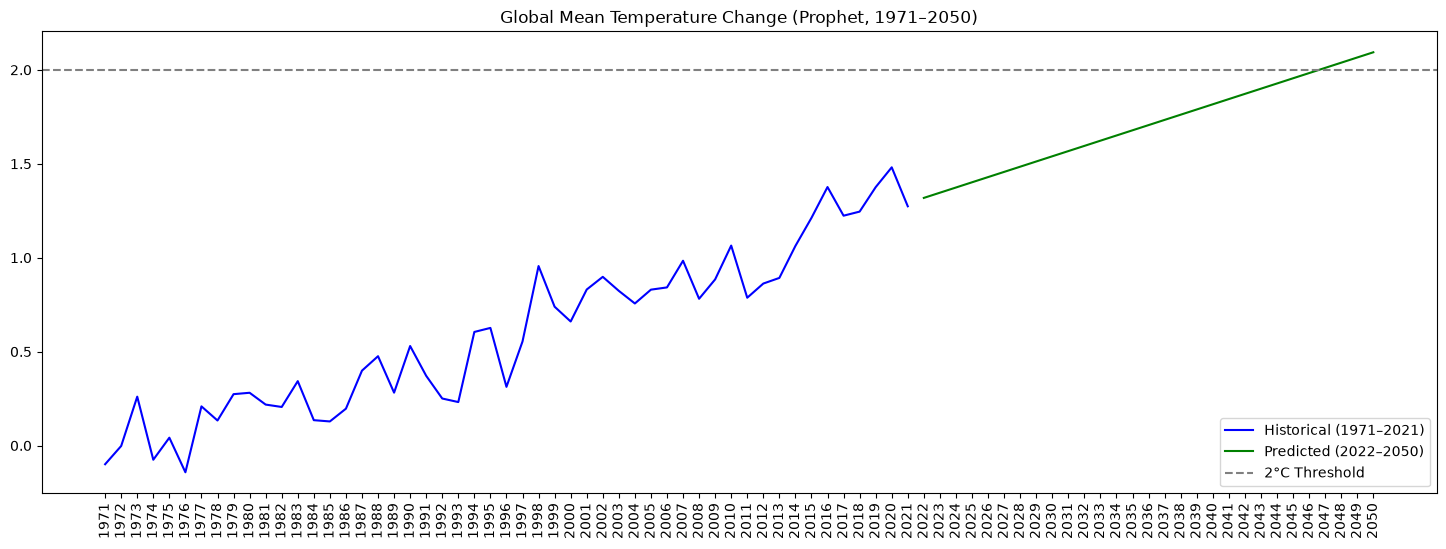

In [48]:
# Historical + predicted line graph (Prophet)
historical_years = sorted(data["year"].unique())
historical_mean = data.pivot(index="Country Name", columns="year", values="temp_anomaly")[historical_years].mean()
future_mean = pred_data_prophet[[str(y) for y in future_years]].mean()

plt.figure(figsize=(18,6))
plt.plot([str(y) for y in historical_years], historical_mean.values, color="blue", label="Historical (1971–2021)")
plt.plot([str(y) for y in future_years], future_mean.values, color="green", label="Predicted (2022–2050)")
plt.axhline(2, color="gray", linestyle="--", label="2°C Threshold")
plt.xticks(rotation=90)
plt.legend()
plt.title("Global Mean Temperature Change (Prophet, 1971–2050)")
plt.show()

In [49]:
# Highest predicted country by 2050
max_row = pred_data_prophet.loc[pred_data_prophet["2050"].idxmax()]
print(max_row["Country"], max_row["2050"])

Armenia, Rep. of 4.515711627380408


In [50]:
# Lowest predicted country by 2050
min_row = pred_data_prophet.loc[pred_data_prophet["2050"].idxmin()]
print(min_row["Country"], min_row["2050"])

Nauru, Rep. of -0.6947865698245411


In [51]:
# Countries predicted to exceed 2°C rise by 2050
baseline = data[data["year"] == 1971][["Country Name", "temp_anomaly"]].rename(columns={"temp_anomaly": "baseline"})
merged = pred_data_prophet.merge(baseline, left_on="Country", right_on="Country Name")
merged["rise_2050"] = merged["2050"] - merged["baseline"]
countries_over_2_2050 = merged[merged["rise_2050"] > 2]["Country"]
print("Number of countries with >2°C rise in 2050:", len(countries_over_2_2050))
print(countries_over_2_2050.tolist())

Number of countries with >2°C rise in 2050: 136
['Albania', 'Algeria', 'Andorra, Principality of', 'Angola', 'Armenia, Rep. of', 'Aruba, Kingdom of the Netherlands', 'Austria', 'Azerbaijan, Rep. of', 'Bahrain, Kingdom of', 'Bangladesh', 'Benin', 'Bhutan', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Chad', 'China, P.R.: Hong Kong', 'China, P.R.: Macao', 'China, P.R.: Mainland', 'Congo, Dem. Rep. of the', 'Congo, Rep. of', 'Cook Islands', 'Cyprus', 'Czech Rep.', 'Denmark', 'Djibouti', 'Dominican Rep.', 'Egypt, Arab Rep. of', 'El Salvador', 'Equatorial Guinea, Rep. of', 'Ethiopia, The Federal Dem. Rep. of', 'Finland', 'France', 'Gambia, The', 'Georgia', 'Germany', 'Ghana', 'Gibraltar', 'Greece', 'Greenland', 'Guatemala', 'Guiana, French', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Holy See', 'Hungary', 'Iceland', 'Iran, Islamic Rep. of', 'Iraq', 'Israel', 'Italy', 'Japan', 'Jordan', 'Kazakhstan, Rep. of', 'Kenya', 'Kiri

In [52]:
# Nepal's predicted temperature change in 2050
nepal_2050 = pred_data_prophet.loc[pred_data_prophet["Country"] == "Nepal", "2050"].values[0]
print("Nepal's predicted temperature change in 2050:", nepal_2050)

Nepal's predicted temperature change in 2050: 1.2997904613119349


In [ ]:
import joblib

# Saving a trained Prophet model for each country, since Prophet works one country at a time
prophet_models = {}

for country_name in prophet_data["Country Name"].unique():
    country_df = prophet_data[prophet_data["Country Name"] == country_name][["ds", "y"]]
    if len(country_df) < 10:
        continue
    model = Prophet(yearly_seasonality=False,weekly_seasonality=False,daily_seasonality=False,changepoint_prior_scale=0.05)
    model.fit(country_df)
    prophet_models[country_name] = model

joblib.dump(prophet_models, "../saved_models/prophet_temperature_models.pkl")
print("All Prophet models saved.")

19:13:37 - cmdstanpy - INFO - Chain [1] start processing
19:13:37 - cmdstanpy - INFO - Chain [1] done processing
19:13:37 - cmdstanpy - INFO - Chain [1] start processing
19:13:37 - cmdstanpy - INFO - Chain [1] done processing
19:13:37 - cmdstanpy - INFO - Chain [1] start processing
19:13:37 - cmdstanpy - INFO - Chain [1] done processing
19:13:38 - cmdstanpy - INFO - Chain [1] start processing
19:13:38 - cmdstanpy - INFO - Chain [1] done processing
19:13:38 - cmdstanpy - INFO - Chain [1] start processing
19:13:38 - cmdstanpy - INFO - Chain [1] done processing
19:13:38 - cmdstanpy - INFO - Chain [1] start processing
19:13:38 - cmdstanpy - INFO - Chain [1] done processing
19:13:38 - cmdstanpy - INFO - Chain [1] start processing
19:13:38 - cmdstanpy - INFO - Chain [1] done processing
19:13:38 - cmdstanpy - INFO - Chain [1] start processing
19:13:39 - cmdstanpy - INFO - Chain [1] done processing
19:13:39 - cmdstanpy - INFO - Chain [1] start processing
19:13:39 - cmdstanpy - INFO - Chain [1]

All Prophet models saved.
